In [74]:
# 1. Imports and Setting professional defaults
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Setting a professional theme to address "Clarity"
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 12, 'axes.titlesize': 14, 'figure.figsize': (10, 6)})

print("Step 1 Success: Libraries imported and visual themes applied.")

Step 1 Success: Libraries imported and visual themes applied.


In [75]:
# 2. Loading the RICH dataset
df = pd.read_csv('StudentPerformanceFactors.csv')
print(f"Step 2 Success: Loaded {df.shape[0]} student records with {df.shape[1]} features.")
df.head()

Step 2 Success: Loaded 6607 student records with 20 features.


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Generating visualizations... please wait.


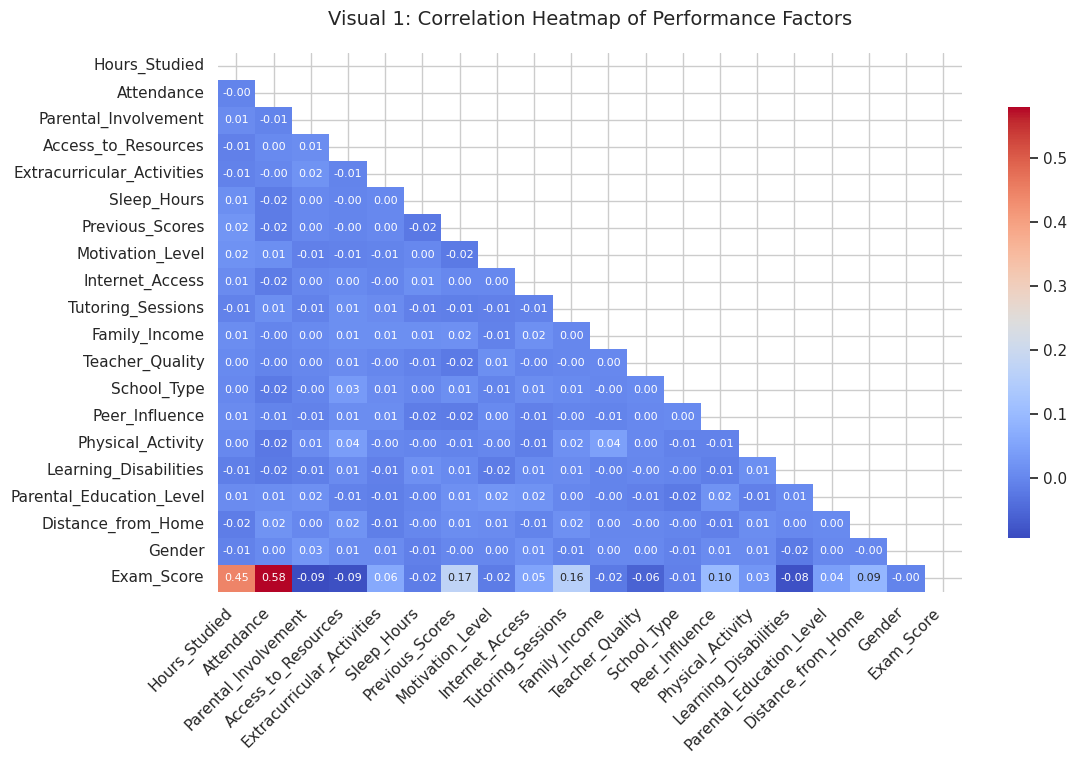

<Figure size 1000x600 with 0 Axes>

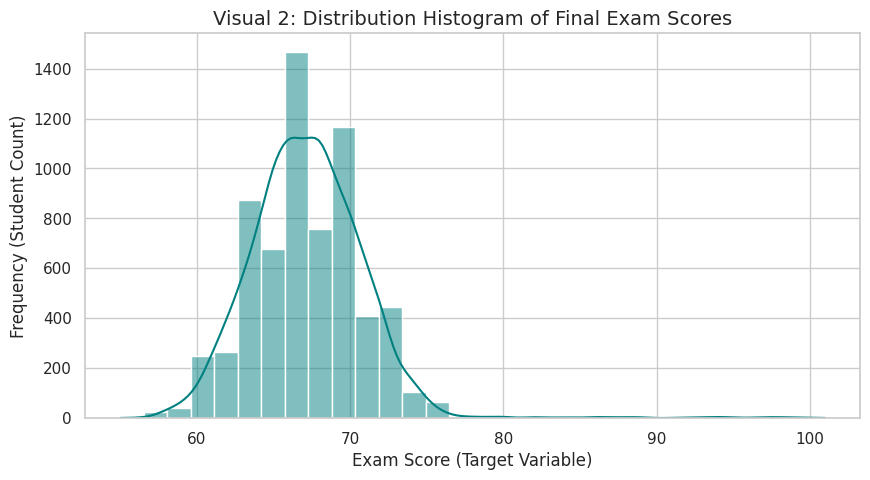

Step 3 Success: Visualizations rendered successfully.


In [76]:
# 3. Requirement: 2 meaningful Visualizations (Optimized for performance)
print("Generating visualizations... please wait.")

# Create a lighter temp copy for visualization
# We drop 'Student_ID' if it exists, as encoding IDs makes the heatmap massive and causes freezing
cols_to_drop = [c for c in ['Student_ID', 'ID'] if c in df.columns]
df_viz = df.drop(columns=cols_to_drop).copy().dropna()

# Efficient Encoding for Heatmap
le = LabelEncoder()
for col in df_viz.select_dtypes(include=['object']).columns:
    df_viz[col] = le.fit_transform(df_viz[col])

# Calculate Correlation ONCE to save memory/processing power
corr_matrix = df_viz.corr()

# Visualization 1: Correlation Heatmap (Optimized)
plt.figure(figsize=(12, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Use the pre-calculated matrix
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            annot_kws={"size": 8}, cbar_kws={"shrink": .8}) # Smaller font for annotations
plt.title("Visual 1: Correlation Heatmap of Performance Factors", pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

# Clear the figure from memory before starting the next one
plt.clf()

# Visualization 2: Distribution Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Exam_Score'], kde=True, color='teal', bins=30) # Specified bins for smoother rendering
plt.title("Visual 2: Distribution Histogram of Final Exam Scores")
plt.xlabel("Exam Score (Target Variable)")
plt.ylabel("Frequency (Student Count)")
plt.show()

print("Step 3 Success: Visualizations rendered successfully.")

In [77]:
# 4. Improvement: Ordinal Mapping for better data quality
df = df.dropna()

# Mapping 'Low', 'Medium', 'High' to 0, 1, 2
rank_map = {'Low': 0, 'Medium': 1, 'High': 2}
ordinal_features = ['Parental_Involvement', 'Motivation_Level', 'Access_to_Resources', 'Family_Income', 'Teacher_Quality']
for col in ordinal_features:
    df[col] = df[col].map(rank_map)

# Label Encoding for other categorical data
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

print(f"Step 4 Success: Cleaned dataset. Categorical variables encoded. Current shape: {df.shape}")

Step 4 Success: Cleaned dataset. Categorical variables encoded. Current shape: (6378, 20)


In [78]:
# 5. Requirement: Standardize the features
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Step 5 Success: Data split into {len(X_train)} training and {len(X_test)} testing samples.")
print("Feature scaling (Standardization) applied to all inputs.")

Step 5 Success: Data split into 5102 training and 1276 testing samples.
Feature scaling (Standardization) applied to all inputs.


In [79]:
# 6. Requirement: Linear Regression optimized using Gradient Descent (SGD)
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True, random_state=42)
train_loss, test_loss = [], []

# Manually iterating to track progress
for epoch in range(500):
    sgd_reg.partial_fit(X_train_scaled, y_train)
    train_loss.append(mean_squared_error(y_train, sgd_reg.predict(X_train_scaled)))
    test_loss.append(mean_squared_error(y_test, sgd_reg.predict(X_test_scaled)))

    # Progress print every 100 epochs for clarity
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/500 - Current Test MSE: {test_loss[-1]:.4f}")

print("Step 6 Success: Gradient Descent optimization complete.")

Epoch 100/500 - Current Test MSE: 4.2862
Epoch 200/500 - Current Test MSE: 4.2860
Epoch 300/500 - Current Test MSE: 4.2860
Epoch 400/500 - Current Test MSE: 4.2860
Epoch 500/500 - Current Test MSE: 4.2860
Step 6 Success: Gradient Descent optimization complete.


In [80]:
# 7. Requirement: Decision Tree and Random Forest models
print("Training alternative models for comparison...")
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train_scaled, y_train)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train_scaled, y_train)

print("Step 7 Success: Decision Tree and Random Forest models trained successfully.")

Training alternative models for comparison...
Step 7 Success: Decision Tree and Random Forest models trained successfully.


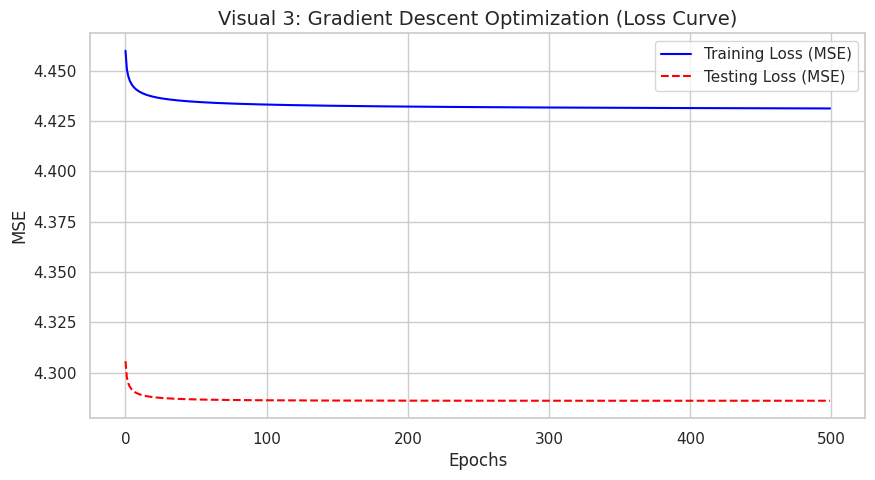

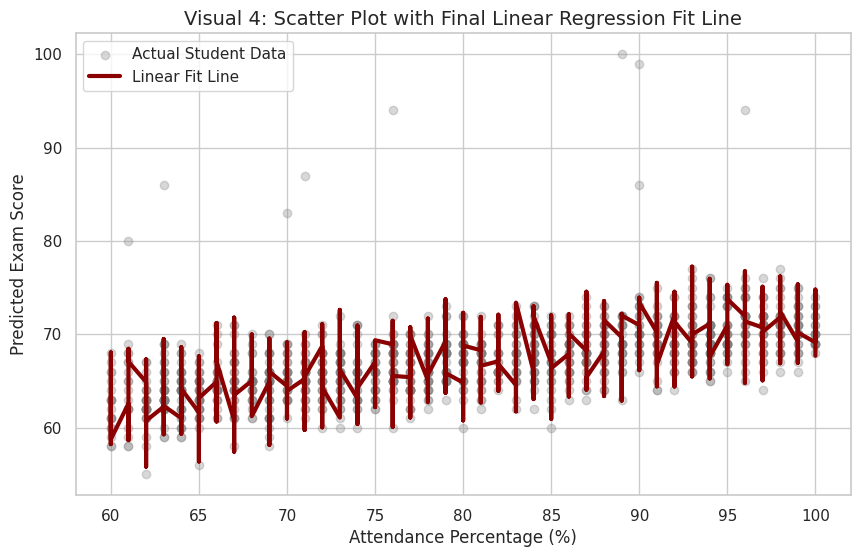

Step 8 Success: Performance and fit visualizations generated.


In [81]:
# 8. Requirement: Scatter Plot with Linear Fit and Loss Curve
# Plot A: Loss Curve
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss (MSE)', color='blue')
plt.plot(test_loss, label='Testing Loss (MSE)', color='red', linestyle='--')
plt.title("Visual 3: Gradient Descent Optimization (Loss Curve)")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend(); plt.show()

# Plot B: Scatter Plot with Regression Fit
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Attendance'], y_test, alpha=0.3, color='gray', label='Actual Student Data')
sort_idx = np.argsort(X_test['Attendance'])
plt.plot(X_test['Attendance'].iloc[sort_idx], sgd_reg.predict(X_test_scaled)[sort_idx],
         color='darkred', linewidth=3, label='Linear Fit Line')
plt.title("Visual 4: Scatter Plot with Final Linear Regression Fit Line")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Predicted Exam Score")
plt.legend(); plt.show()

print("Step 8 Success: Performance and fit visualizations generated.")

In [82]:
# 9. Requirement: Save the model with the Least Loss
mse_results = {
    'Linear Regression': mean_squared_error(y_test, sgd_reg.predict(X_test_scaled)),
    'Decision Tree': mean_squared_error(y_test, dt_reg.predict(X_test_scaled)),
    'Random Forest': mean_squared_error(y_test, rf_reg.predict(X_test_scaled))
}
best_name = min(mse_results, key=mse_results.get)
best_model = {'Linear Regression': sgd_reg, 'Decision Tree': dt_reg, 'Random Forest': rf_reg}[best_name]

print(f"Step 9 Results: \n- LR MSE: {mse_results['Linear Regression']:.4f}\n- DT MSE: {mse_results['Decision Tree']:.4f}\n- RF MSE: {mse_results['Random Forest']:.4f}")
print(f"--- WINNER: {best_name} ---")

joblib.dump(best_model, 'best_educational_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print(f"Step 9 Success: Saved '{best_name}' and 'scaler.pkl' for Task 2.")

Step 9 Results: 
- LR MSE: 4.2860
- DT MSE: 7.6158
- RF MSE: 5.8336
--- WINNER: Linear Regression ---
Step 9 Success: Saved 'Linear Regression' and 'scaler.pkl' for Task 2.


In [83]:
# 10. Requirement: Prediction on one row of the test data
sample_data = X_test_scaled[20].reshape(1, -1)
final_prediction = best_model.predict(sample_data)[0]

print(f"--- Task 2 Simulation: Final Prediction Test ---")
print(f"Input features for sample #20 processed.")
print(f"Model Outcome (Predicted Score): {final_prediction:.2f}")
print(f"Ground Truth (Actual Score): {y_test.iloc[20]}")
print(f"Prediction Variance: {abs(final_prediction - y_test.iloc[20]):.2f}")

--- Task 2 Simulation: Final Prediction Test ---
Input features for sample #20 processed.
Model Outcome (Predicted Score): 64.44
Ground Truth (Actual Score): 64
Prediction Variance: 0.44
